# pypgo Animation & Stress Field API Demo

This notebook covers two related pipelines:

**Animation export**

**Stress field**

Both pipelines consume the standard simulation output layout:

```
sim_output/
  states/deform{frame:04d}.u       ← per-frame displacement (3n × 1 Eigen binary)
  stress/von_mises{frame:04d}.json  ← per-element von Mises values
```

Synthetic data is generated throughout so the notebook runs without any
real simulation output.


In [16]:
import json
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pypgo as pgo

from pypgo.animation import (
    AbcWriter,
    dump_animation,
    dump_stress_vdb,
    has_animation_io,
    has_stress_vdb_export,
    write_u_file,
)
from pypgo.mesh import TriMeshData
from pypgo.mesh.volume import read_veg
from pypgo.animation import compute_stress_field_stats
from pypgo.mesh.visualize import plot_surface

def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Could not find repository root")

REPO_ROOT = _find_repo_root()
ASSET_DIR = REPO_ROOT / "examples" / "assets" / "obj"
VEG_DIR   = REPO_ROOT / "examples" / "assets" / "veg" / "tet"

tmpdir = Path(tempfile.mkdtemp())

print("Animation IO available :", has_animation_io())
print("Stress VDB available   :", has_stress_vdb_export())


Animation IO available : True
Stress VDB available   : True


## 1. Mesh and synthetic displacements

Load `box.obj` as the surface mesh. Generate `N_FRAMES` of smooth
sinusoidal displacement — a translation along x with a y wobble.


In [17]:
N_FRAMES = 48

box = pgo.mesh.read_obj(str(ASSET_DIR / "box.obj"))
print(f"box: {box.num_vertices} vertices, {box.num_elements} triangles")

t = np.linspace(0, 2 * np.pi, N_FRAMES, endpoint=False)
amplitude = float(box.bbox[1][0] - box.bbox[0][0]) * 0.5

displacements = np.zeros((N_FRAMES, box.num_vertices * 3))
displacements[:, 0::3] = amplitude * np.sin(t)[:, None]
displacements[:, 1::3] = amplitude * 0.3 * np.sin(2 * t)[:, None]

print(f"amplitude: {amplitude:.4f},  shape: {displacements.shape}")


box: 194 vertices, 384 triangles
amplitude: 0.2500,  shape: (48, 582)


## 2. Visualize keyframes


In [3]:
rest_verts = box.vertices.copy()
keyframes  = [0, N_FRAMES // 4, N_FRAMES // 2, 3 * N_FRAMES // 4]
key_meshes = [
    TriMeshData(rest_verts + displacements[f].reshape(-1, 3), box.elements)
    for f in keyframes
]

plot_surface(
    key_meshes,
    titles=[f"frame {f} / {N_FRAMES}" for f in keyframes],
    show_edges=True,
    colors=["lightgray", "cornflowerblue", "mediumseagreen", "lightsalmon"],
    window_size=(1200, 360),
)


Widget(value='<iframe src="http://localhost:60079/index.html?ui=P_0x10422d7f0_0&reconnect=auto" class="pyvista…

## 3. Incremental export: `AbcWriter`

``AbcWriter`` accumulates displacement frames one at a time and writes
the ``.abc`` file in one shot. Use it as a context manager for automatic
finalisation, or call ``add_frame`` / ``write`` manually.


In [4]:
abc_low = tmpdir / "box_lowlevel.abc"

with AbcWriter(abc_low, "box",
               rest_positions=box.vertices.ravel(),
               triangles=box.elements.ravel()) as w:
    for f in range(N_FRAMES):
        w.add_frame(displacements[f])

print(f"Written: {abc_low}  ({abc_low.stat().st_size / 1024:.1f} KB)")


Writing: /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/box_lowlevel.abc
Written: /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/box_lowlevel.abc  (121.8 KB)


## 4. Config-driven export: `dump_animation`

``dump_animation`` is the one-shot convenience: it loads a JSON config
file and exports all meshes to the target folder in one call.

Here we use ``"sequence-type": "objmesh"`` — each frame is an
individual ``.obj`` file containing the deformed vertex positions.


In [5]:
frame_dir = tmpdir / "obj_frames"
frame_dir.mkdir()

for f in range(N_FRAMES):
    frame_verts = rest_verts + displacements[f].reshape(-1, 3)
    pgo.mesh.write_obj(str(frame_dir / f"frame_{f:04d}.obj"),
                       TriMeshData(frame_verts, box.elements))

config_single = {
    "meshes": [
        {
            "name": "box_oscillation",
            "driving-mesh": str(ASSET_DIR / "box.obj"),
            "sequence": str(frame_dir / "frame_{:04d}.obj"),
            "sequence-type": "objmesh",
            "sequence-range": [0, N_FRAMES],
        }
    ]
}
json_path = tmpdir / "config_single.json"
json_path.write_text(json.dumps(config_single, indent=2))

dump_animation(json_path, tmpdir)

abc_hl = tmpdir / "box_oscillation.abc"
print(f"Written: {abc_hl}  ({abc_hl.stat().st_size / 1024:.1f} KB)")


Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0000.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0001.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0002.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0003.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0004.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0005.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0006.obj.
Saved mesh (#v: 194, #t: 384) to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/obj_frames/frame_0007.obj.
Saved mesh (#v: 194, #t: 384) to

## 5. Multi-sequence export with `dump_animation`

Multiple meshes can be exported by listing them in the same JSON config.
Each ``"meshes"`` entry becomes one ``.abc`` file.


In [6]:
config_multi = {
    "meshes": [
        {
            "name": "box_sin",
            "driving-mesh": str(ASSET_DIR / "box.obj"),
            "sequence": str(frame_dir / "frame_{:04d}.obj"),
            "sequence-type": "objmesh",
            "sequence-range": [0, N_FRAMES],
            "scale": "1,1,1",
        },
        {
            "name": "box_sin_half",
            "driving-mesh": str(ASSET_DIR / "box.obj"),
            "sequence": str(frame_dir / "frame_{:04d}.obj"),
            "sequence-type": "objmesh",
            "sequence-range": [0, N_FRAMES],
            "gap": 2,
            "scale": "1,1,0.5",
        },
    ]
}

out_dir = tmpdir / "multi"
json_multi = tmpdir / "config_multi.json"
json_multi.write_text(json.dumps(config_multi, indent=2))

dump_animation(json_multi, out_dir)

for abc in sorted(out_dir.glob("*.abc")):
    print(f"  {abc.name}  ({abc.stat().st_size / 1024:.1f} KB)")


0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 0 2 4 6 8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 Writing: /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/multi/box_sin.abc
Writing: /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/multi/box_sin_half.abc
  box_sin.abc  (121.8 KB)
  box_sin_half.abc  (64.5 KB)


## 6. Synthetic stress simulation data

The stress pipeline expects the standard simulation output layout. Here we generate
synthetic data from `bunny.veg`:

- **Displacements** — a "breathing" animation: vertices oscillate radially
  toward and away from the mesh centroid.
- **Stress** — per-element von Mises values drawn from a Gaussian whose
  mean varies sinusoidally over time, mimicking a stress wave.


In [7]:
N_STRESS_FRAMES = 24
rng = np.random.default_rng(42)

veg     = read_veg(str(VEG_DIR / "bunny.veg"))
md_mesh = veg.mesh_data
n_verts = md_mesh.num_vertices
n_elems = md_mesh.num_elements
print(f"bunny.veg: {n_verts} vertices, {n_elems} tet elements")

centroid  = md_mesh.vertices.mean(axis=0)
radial    = md_mesh.vertices - centroid
radial   /= np.linalg.norm(radial, axis=1, keepdims=True).clip(1e-8)
bbox_diag = float(np.linalg.norm(
    md_mesh.vertices.max(axis=0) - md_mesh.vertices.min(axis=0)))
breath_amp = bbox_diag * 0.04

ts         = np.linspace(0, 2 * np.pi, N_STRESS_FRAMES, endpoint=False)
sim_dir    = tmpdir / "stress_sim"
states_dir = sim_dir / "states"
stress_dir = sim_dir / "stress"
states_dir.mkdir(parents=True)
stress_dir.mkdir()

for f in range(N_STRESS_FRAMES):
    disp = (radial * (breath_amp * np.sin(ts[f]))).ravel()[:, None]  # (3n, 1)
    write_u_file(states_dir / f"deform{f:04d}.u", disp)

    stress_mean = 1500.0 + 800.0 * np.sin(ts[f])
    values = np.abs(rng.normal(stress_mean, stress_mean * 0.25, n_elems))
    with open(stress_dir / f"von_mises{f:04d}.json", "w") as fp:
        json.dump({
            "frame": f, "time": f / 24.0,
            "stress_type": "von_mises", "location": "element",
            "values": values.tolist(),
        }, fp)

print(f"Wrote {N_STRESS_FRAMES} frames to {sim_dir}")


bunny.veg: 203 vertices, 579 tet elements
Wrote 24 frames to /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/stress_sim


## 7. `compute_stress_field_stats`

Aggregates per-frame statistics (min, mean, stddev, median, p99, max)
and saves a single summary JSON with stress statistics
tool format exactly. Works for **any mesh type** — tet or cubic — because
it only reads the JSON files and is mesh-agnostic.


In [8]:
stats = compute_stress_field_stats(
    stress_dir,
    prefix="von_mises",
    frame_start=0,
    frame_end=N_STRESS_FRAMES,
)

print(f"stress_type : {stats.stress_type!r}")
print(f"frames      : {stats.num_frames}")
print()
print(f"{'frame':>5}  {'time':>6}  {'mean':>8}  {'p99':>8}  {'max':>8}")
print("-" * 44)
for s in stats.frames:
    print(f"{s.frame:>5}  {s.time:>6.3f}  {s.mean:>8.1f}  {s.p99:>8.1f}  {s.max:>8.1f}")


stress_type : 'von_mises'
frames      : 24

frame    time      mean       p99       max
--------------------------------------------
    0   0.000    1493.6    2318.5    2592.7
    1   0.042    1700.3    2603.5    3063.7
    2   0.083    1859.6    2998.8    3284.3
    3   0.125    2032.3    3248.7    3541.3
    4   0.167    2211.1    3544.7    3870.1
    5   0.208    2286.8    3617.3    4027.6
    6   0.250    2298.5    3695.9    3936.0
    7   0.292    2282.3    3620.1    4235.3
    8   0.333    2143.5    3382.8    3835.4
    9   0.375    2100.9    3326.3    3739.5
   10   0.417    1928.7    3071.1    3423.9
   11   0.458    1704.8    2659.6    2902.0
   12   0.500    1497.0    2330.2    2735.2
   13   0.542    1286.2    1996.5    2594.2
   14   0.583    1105.5    1701.4    1857.2
   15   0.625     928.1    1446.4    1736.9
   16   0.667     794.3    1331.3    1425.6
   17   0.708     719.6    1138.4    1280.9
   18   0.750     703.6    1080.1    1247.1
   19   0.792     723.7    1160

In [9]:
summary_path = sim_dir / "stress_stats.json"
stats.save(summary_path)
print(f"Saved: {summary_path}  ({summary_path.stat().st_size} bytes)")

with open(summary_path) as fp:
    doc = json.load(fp)
print("top-level keys:", list(doc.keys()))
print("frame[0]:", doc["frames"][0])


Saved: /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/stress_sim/stress_stats.json  (7035 bytes)
top-level keys: ['stress_type', 'location', 'source_dir', 'prefix', 'frame_start', 'frame_end', 'num_frames', 'frames']
frame[0]: {'frame': 0, 'time': 0.0, 'count': 579, 'min': 388.3016858093808, 'mean': 1493.5719488410568, 'stddev': 361.12891848558405, 'median': 1498.0792999799733, 'p99': 2318.4633040331637, 'max': 2592.6984247527485}


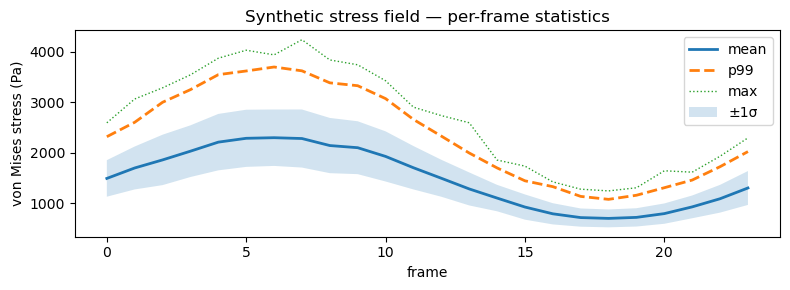

In [10]:
try:
    import matplotlib.pyplot as plt

    frames_idx = [s.frame for s in stats.frames]
    means  = [s.mean  for s in stats.frames]
    p99s   = [s.p99   for s in stats.frames]
    maxs   = [s.max   for s in stats.frames]

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(frames_idx, means, label="mean",  linewidth=2)
    ax.plot(frames_idx, p99s,  label="p99",   linewidth=2, linestyle="--")
    ax.plot(frames_idx, maxs,  label="max",   linewidth=1, linestyle=":")
    ax.fill_between(frames_idx,
                    [s.mean - s.stddev for s in stats.frames],
                    [s.mean + s.stddev for s in stats.frames],
                    alpha=0.2, label="±1σ")
    ax.set_xlabel("frame")
    ax.set_ylabel("von Mises stress (Pa)")
    ax.set_title("Synthetic stress field — per-frame statistics")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed — skipping plot (mamba install matplotlib).")


## 8. `dump_stress_vdb` — OpenVDB export

`dump_stress_vdb` reads the `states/` and `stress/` layout and writes one
`.vdb` file per frame. Each file contains a `FloatGrid` named `"von_mises"`
splatted at the deformed tet element positions.

> **Tet-only limitation.** `dump_stress_vdb` uses `StressFieldVDBExporter`
> internally, which only supports **tetrahedral** meshes. Cubic hex meshes
> are not supported for VDB export. Use `compute_stress_field_stats` (section 7)
> for mesh-agnostic per-frame statistics on hex outputs.

`voxel_size=0.0` auto-derives the voxel size from ~½ the rest mesh's average
tet edge length.


In [11]:
if has_stress_vdb_export():
    vdb_dir = sim_dir / "vdb"
    n_written = dump_stress_vdb(
        veg_path=VEG_DIR / "bunny.veg",
        sim_output=sim_dir,
        output_dir=vdb_dir,
        prefix="vonMises",
        voxel_size=0.0,
        frame_start=0,
        frame_end=N_STRESS_FRAMES,
    )

    vdb_files = sorted(vdb_dir.glob("*.vdb"))
    print(f"Wrote {n_written} VDB frames to {vdb_dir}")
    print()
    print(f"{'file':<26}  {'size (KB)':>10}")
    print("-" * 40)
    for vf in vdb_files:
        print(f"{vf.name:<26}  {vf.stat().st_size / 1024:>10.1f}")
else:
    print("Skipping: OpenVDB not available in this build.")
    print("Reconfigure with PGO_ENABLE_OPENVDB=ON to enable VDB export.")


Opening file /Users/jinceyang/Desktop/codebase/libpgo/examples/assets/veg/tet/bunny.veg.
[2026-06-07 23:37:38.528] [info] [stressFieldVDBExporter.cpp:66] StressFieldVDBExporter: loaded /Users/jinceyang/Desktop/codebase/libpgo/examples/assets/veg/tet/bunny.veg (203 vertices, 579 tets)
[2026-06-07 23:37:38.529] [info] [stressFieldVDBExporter.cpp:116] StressFieldVDBExporter: loaded 24 deformation frames from /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/stress_sim/states
[2026-06-07 23:37:38.532] [info] [stressFieldVDBExporter.cpp:181] StressFieldVDBExporter: loaded 24 stress frames from /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/stress_sim/stress
[2026-06-07 23:37:38.549] [info] [stressFieldVDBExporter.cpp:289] StressFieldVDBExporter: wrote frame 0 -> /var/folders/lw/j9_lmxtd6gx45dln0mlczmn80000gn/T/tmp_5txoq3s/stress_sim/vdb/vonMises0000.vdb
[2026-06-07 23:37:38.555] [info] [stressFieldVDBExporter.cpp:289] StressFieldVDBExporter: wrote frame 1 -> /var/fo

## 9. Cleanup


In [12]:
shutil.rmtree(tmpdir)
print("Temporary files removed.")


Temporary files removed.
